# EDA — synthetic imuGAP input data

The data comes from the R engine `simulate_imuGAP_data()`: a State → 3 counties → 24 schools hierarchy across three observation streams. We regenerate the three tables (deterministic, seed 93254) and explore the **input** data only — coverage-by-age estimates come from the model later.

In [ ]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize":   (8, 4.5),
    "figure.dpi":       110,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "savefig.bbox":     "tight",
})

BLUE, HERD = "#4C72B0", 0.95

In [ ]:
ROOT = Path.cwd()
while not (ROOT / "raw-data" / "simulate_imuGAP_data.R").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

R_GEN = """
suppressMessages({library(data.table); library(dplyr)})
source("raw-data/simulate_imuGAP_data.R")
sim <- simulate_imuGAP_data()
dir.create("data/derived/sim", showWarnings = FALSE, recursive = TRUE)
fwrite(sim$observations, "data/derived/sim/observations.csv")
fwrite(sim$locations,    "data/derived/sim/locations.csv")
"""
subprocess.run(["Rscript", "-e", R_GEN], cwd=ROOT, check=True)

obs       = pd.read_csv(ROOT / "data/derived/sim/observations.csv")
locations = pd.read_csv(ROOT / "data/derived/sim/locations.csv")
obs["frac"] = obs.positive / obs.sample_n

## Hierarchy

In [ ]:
level = np.where(locations.parent_id.isna(), "state",
         np.where(locations.parent_id == "State", "county", "school"))
locations.assign(level=level).level.value_counts().reindex(["state", "county", "school"])

level
state      1
county     3
school    24
Name: count, dtype: int64

## Observation streams

Rows split into three State-level streams (`child`, `teen`, `school`) and the per-school kindergarten records (`vaxview_type` is missing). The per-school records track 2-dose MMR; MCV1 (dose 1) is observed only at the State level, in the `child` stream.

In [ ]:
obs["stream"] = obs.vaxview_type.fillna("school (per-unit)")
(obs.groupby("stream")
    .agg(rows=("obs_id", "size"),
         years=("year", lambda s: f"{s.min()}-{s.max()}"),
         mean_frac=("frac", lambda s: round(s.mean(), 3)))
    .reset_index())

,stream,rows,years,mean_frac
0,child,60,1996-2025,0.837
1,school,25,2001-2025,0.854
2,school (per-unit),600,2001-2025,0.880
3,teen,13,2013-2025,0.895


In [ ]:
schools = obs[obs.vaxview_type.isna()].copy()
state   = obs[obs.vaxview_type.notna()].copy()

## State child stream over time

`positive / sample_n` is the observed vaccinated fraction (`phi_st` × dose-1 uptake × 0.95), not raw coverage.

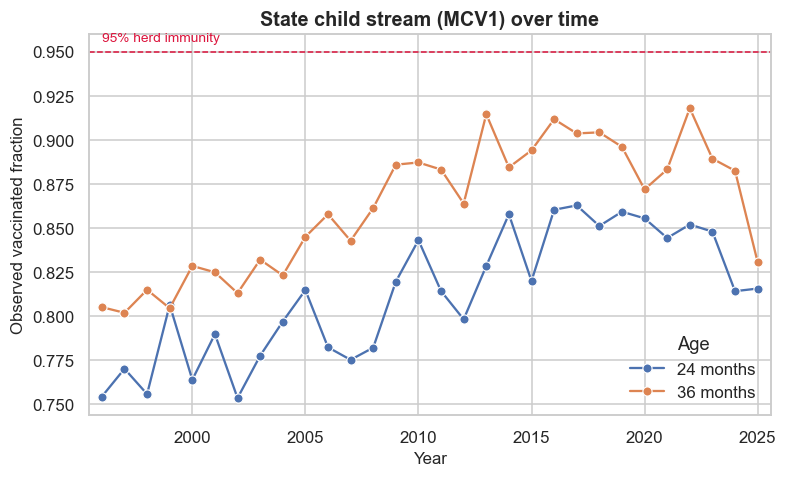

In [ ]:
child = state[state.vaxview_type == "child"]

fig, ax = plt.subplots()
sns.lineplot(data=child, x="year", y="frac", hue="age", marker="o", ax=ax)
ax.axhline(HERD, ls="--", color="crimson", lw=1)
ax.text(child.year.min(), HERD + 0.004, "95% herd immunity",
        color="crimson", fontsize=9, va="bottom")
ax.set(xlabel="Year", ylabel="Observed vaccinated fraction",
       title="State child stream (MCV1) over time")
ax.legend(title="Age", frameon=False)
ax.margins(x=0.02)
plt.show()

Both series climb from the mid-0.70s to ~0.85–0.91 then dip after 2023, tracing the `phi_st` cohort curve. The 36-month series stays above 24-month throughout, and neither reaches 95%.

## School-level coverage distribution

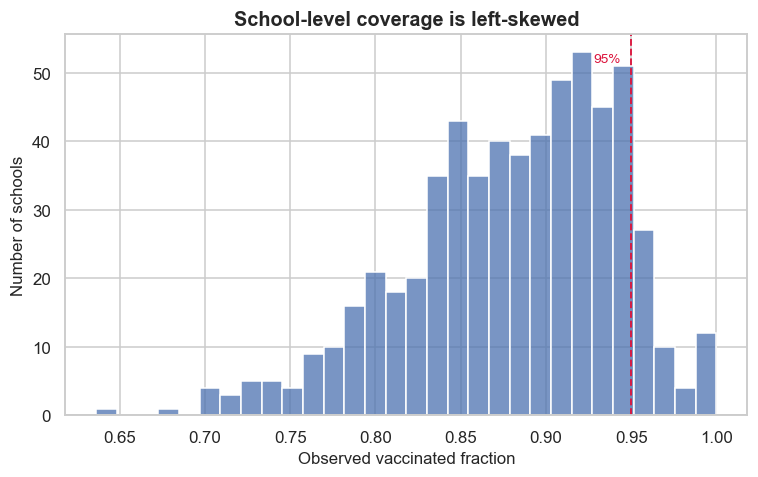

In [ ]:
fig, ax = plt.subplots()
sns.histplot(schools.frac, bins=30, color=BLUE, edgecolor="white", ax=ax)
ax.axvline(HERD, ls="--", color="crimson", lw=1.2)
ax.text(HERD - 0.006, ax.get_ylim()[1] * 0.95, "95%",
        color="crimson", ha="right", va="top", fontsize=9)
ax.set(xlabel="Observed vaccinated fraction", ylabel="Number of schools",
       title="School-level coverage is left-skewed")
plt.show()

Left-skewed (skew ≈ −0.6, median 0.89) with a long low tail; the large majority of schools sit below the 95% line.

## School size vs observed coverage

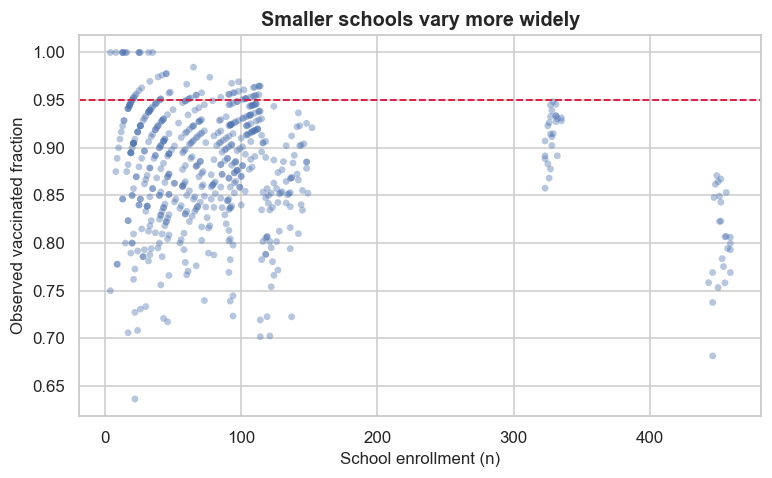

In [ ]:
fig, ax = plt.subplots()
ax.scatter(schools.sample_n, schools.frac, s=20, alpha=0.4, color=BLUE, edgecolor="none")
ax.axhline(HERD, ls="--", color="crimson", lw=1.2)
ax.set(xlabel="School enrollment (n)", ylabel="Observed vaccinated fraction",
       title="Smaller schools vary more widely")
plt.show()

A clear funnel: small schools span 0.65–1.0 while large ones cluster tightly (sd 0.08 at n<30 vs ~0.06 at n>80). The spread is binomial sampling noise, not a real coverage difference.

## Coverage by county

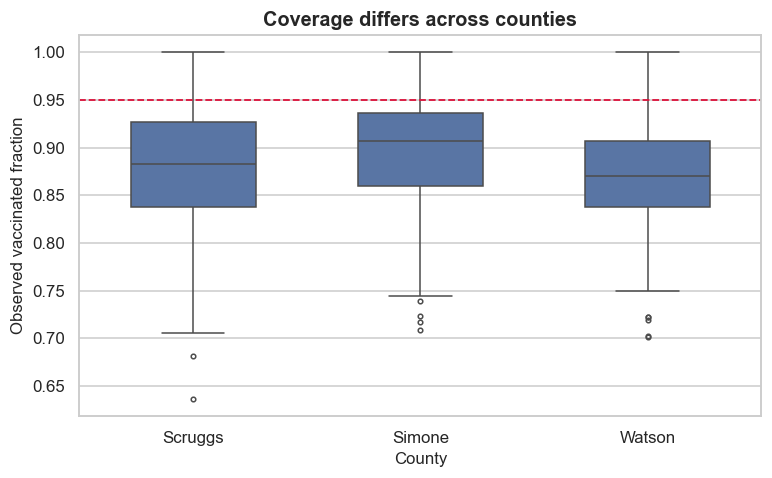

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(data=schools, x="parent_id", y="frac", ax=ax, color=BLUE, width=0.55, fliersize=3)
ax.axhline(HERD, ls="--", color="crimson", lw=1.2)
ax.set(xlabel="County", ylabel="Observed vaccinated fraction",
       title="Coverage differs across counties")
plt.show()

Simone highest (median ~0.91), Watson lowest (~0.87); modest shifts from the county-level random effects, with all county medians below 95%.